Retail Sales Intelligence — Data Exploration
# Business Intelligence Project |Aziz iben hadj abdallah| 2026
**Objective:** Explore 10,000+ retail transactions to identify revenue drivers and performance gaps using SQL in Python.

In [2]:
!pip install pandasql -q

import pandas as pd
import pandasql as ps
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style("whitegrid")

print(" All libraries loaded successfully")

 All libraries loaded successfully


In [4]:
from google.colab import files
uploaded = files.upload()

Saving Sample - Superstore.csv to Sample - Superstore.csv


In [5]:
import io

df = pd.read_csv(io.BytesIO(list(uploaded.values())[0]), encoding='latin-1')

print(f" Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

 Dataset loaded: 9,994 rows × 21 columns


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


##  Section 1 — Data Quality Check
 verify the data is clean and complete.

In [10]:

print("         DATASET OVERVIEW")
print(f"\n Total Orders:    {df['Order ID'].nunique():,}")
print(f"Total Customers: {df['Customer ID'].nunique():,}")
print(f"  Total Products:  {df['Product Name'].nunique():,}")
print(f" Date Range:      {df['Order Date'].min()} → {df['Order Date'].max()}")
print(f"\n Missing Values:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "   No missing values found")

         DATASET OVERVIEW

 Total Orders:    5,009
Total Customers: 793
  Total Products:  1,850
 Date Range:      2014-01-03 00:00:00 → 2017-12-30 00:00:00

 Missing Values:
   No missing values found


In [11]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

print(f" Date Range: {df['Order Date'].min().date()} → {df['Order Date'].max().date()}")

 Date Range: 2014-01-03 → 2017-12-30


##  Section 2 — Executive KPI Summary
**Business Question:** What is the overall financial performance of the business?

In [16]:
query = """
SELECT
    ROUND(SUM(Sales), 2)                              AS Total_Revenue,
    ROUND(SUM(Profit), 2)                             AS Total_Profit,
    ROUND(SUM(Profit) / SUM(Sales) * 100, 2)          AS Profit_Margin_Pct,
    COUNT(DISTINCT [Order ID])                         AS Total_Orders,
    ROUND(SUM(Sales) / COUNT(DISTINCT [Order ID]), 2) AS Avg_Order_Value
FROM df
"""
kpis = ps.sqldf(query)
print("       EXECUTIVE KPI SUMMARY")
print(f"   Total Revenue:    ${kpis['Total_Revenue'][0]:,.2f}")
print(f"   Total Profit:     ${kpis['Total_Profit'][0]:,.2f}")
print(f"   Profit Margin:    {kpis['Profit_Margin_Pct'][0]}%")
print(f"   Total Orders:     {kpis['Total_Orders'][0]:,}")
print(f"   Avg Order Value:  ${kpis['Avg_Order_Value'][0]:,.2f}")

       EXECUTIVE KPI SUMMARY
   Total Revenue:    $2,297,200.86
   Total Profit:     $286,397.02
   Profit Margin:    12.47%
   Total Orders:     5,009
   Avg Order Value:  $458.61


##  Section 3 — Category Performance
**Business Question:** Which product categories drive the most revenue and profit?**texte en gras**

,Category,Total_Revenue,Total_Profit,Profit_Margin_Pct,Total_Orders
0,Technology,836154.03,145454.95,17.40,1544
1,Furniture,741999.80,18451.27,2.49,1764
2,Office Supplies,719047.03,122490.80,17.04,3742


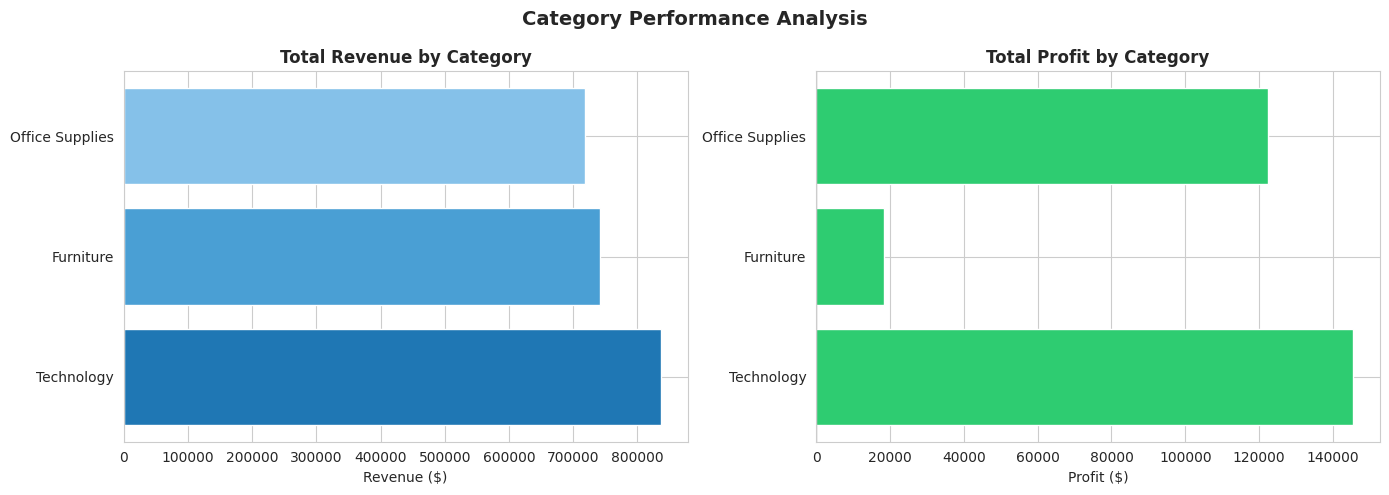

In [17]:
query = """
SELECT
    Category,
    ROUND(SUM(Sales), 2)                      AS Total_Revenue,
    ROUND(SUM(Profit), 2)                     AS Total_Profit,
    ROUND(SUM(Profit)/SUM(Sales)*100, 2)      AS Profit_Margin_Pct,
    COUNT(DISTINCT [Order ID])                 AS Total_Orders
FROM df
GROUP BY Category
ORDER BY Total_Revenue DESC
"""
cat_df = ps.sqldf(query)
display(cat_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(cat_df['Category'], cat_df['Total_Revenue'], color=['#1f77b4','#4a9fd4','#85c1e9'])
axes[0].set_title('Total Revenue by Category', fontweight='bold')
axes[0].set_xlabel('Revenue ($)')

colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in cat_df['Total_Profit']]
axes[1].barh(cat_df['Category'], cat_df['Total_Profit'], color=colors)
axes[1].set_title('Total Profit by Category', fontweight='bold')
axes[1].set_xlabel('Profit ($)')
axes[1].axvline(0, color='black', linewidth=0.8)

plt.suptitle('Category Performance Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('category_performance.png', dpi=150, bbox_inches='tight')
plt.show()

#  Section 4 — Loss-Making Products
**Business Question:** Which products are actively losing money?

,Product Name,Category,Sub-Category,Total_Revenue,Total_Profit,Times_Ordered
0,Cubify CubeX 3D Printer Double Head Print,Technology,Machines,11099.96,-8879.97,3
1,Lexmark MX611dhe Monochrome Laser Printer,Technology,Machines,16829.90,-4589.97,4
2,Cubify CubeX 3D Printer Triple Head Print,Technology,Machines,7999.98,-3839.99,1
3,Chromcraft Bull-Nose Wood Oval Conference Tabl...,Furniture,Tables,9917.64,-2876.12,5
4,Bush Advantage Collection Racetrack Conference...,Furniture,Tables,9544.73,-1934.40,7
5,GBC DocuBind P400 Electric Binding System,Office Supplies,Binders,17965.07,-1878.17,6
6,Cisco TelePresence System EX90 Videoconferenci...,Technology,Machines,22638.48,-1811.08,1
7,Martin Yale Chadless Opener Electric Letter Op...,Office Supplies,Supplies,16656.20,-1299.18,6
8,Balt Solid Wood Round Tables,Furniture,Tables,6518.75,-1201.06,4
9,BoxOffice By Design Rectangular and Half-Moon ...,Furniture,Tables,1706.25,-1148.44,3


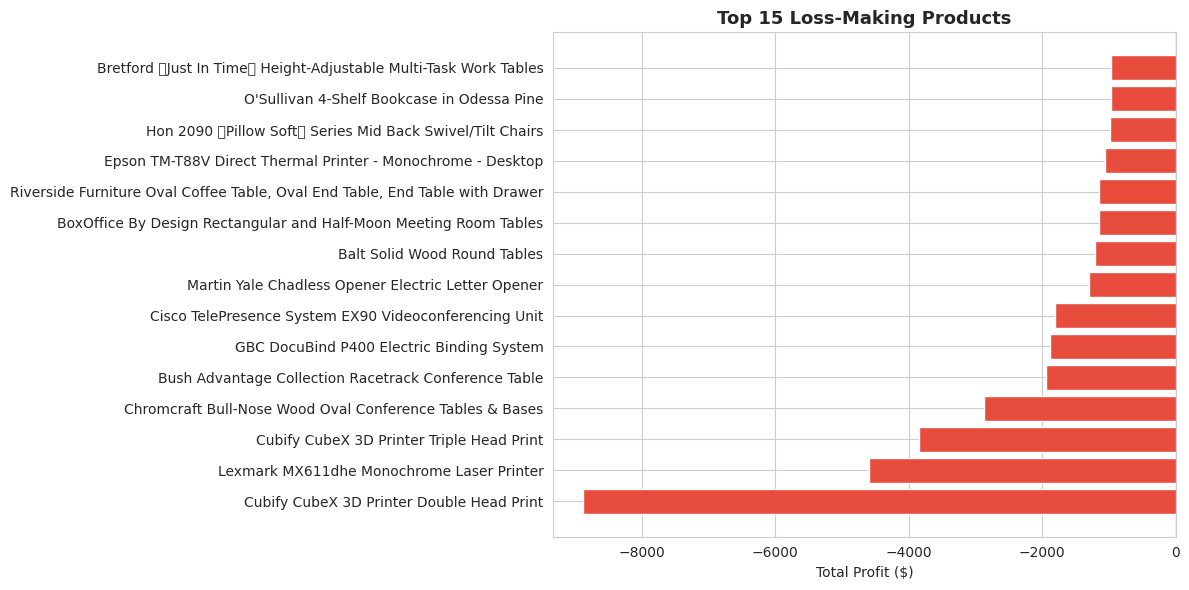


 Insight: 15 products shown are operating at a loss


In [18]:
query = """
SELECT
    [Product Name],
    Category,
    [Sub-Category],
    ROUND(SUM(Sales), 2)    AS Total_Revenue,
    ROUND(SUM(Profit), 2)   AS Total_Profit,
    COUNT([Order ID])        AS Times_Ordered
FROM df
GROUP BY [Product Name]
HAVING Total_Profit < 0
ORDER BY Total_Profit ASC
LIMIT 15
"""
loss_df = ps.sqldf(query)
display(loss_df)

plt.figure(figsize=(12, 6))
plt.barh(loss_df['Product Name'], loss_df['Total_Profit'], color='#e74c3c')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top 15 Loss-Making Products', fontweight='bold', fontsize=13)
plt.xlabel('Total Profit ($)')
plt.tight_layout()
plt.savefig('loss_makers.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n Insight: {len(loss_df)} products shown are operating at a loss")

##  Section 5 — Sales Trend Over Time
*Business Question:* Is the business growing year over year?

,Year,Annual_Revenue,Annual_Profit,Total_Orders,Revenue_Growth_Pct
0,2014,484247.50,49543.97,969,NaN
1,2015,470532.51,61618.60,1038,-2.83
2,2016,609205.60,81795.17,1315,29.47
3,2017,733215.26,93439.27,1687,20.36


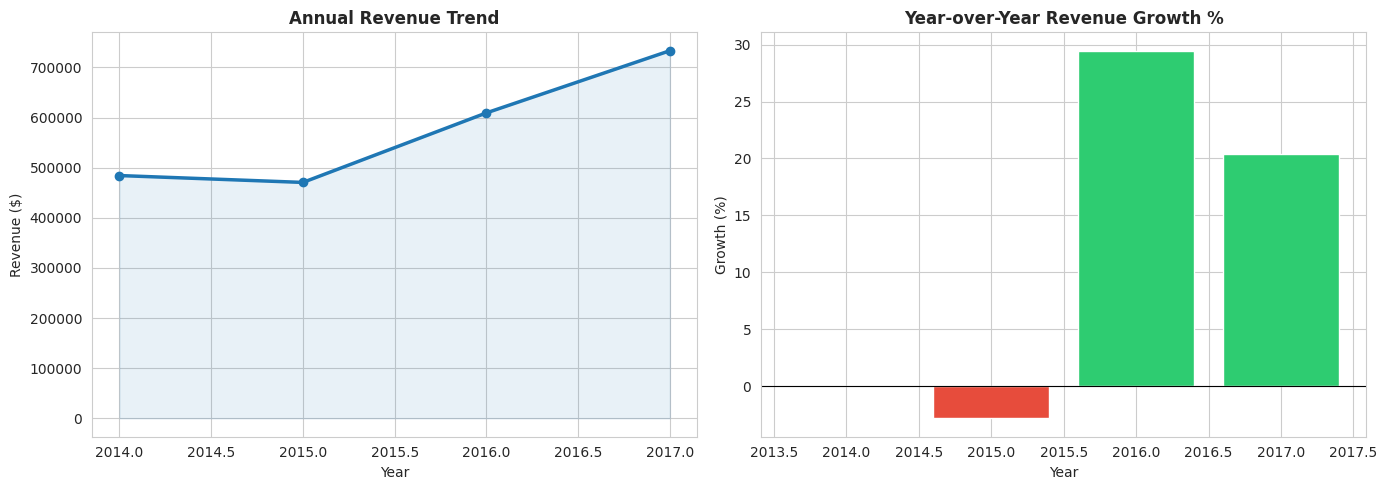

In [19]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

query = """
SELECT
    Year,
    ROUND(SUM(Sales), 2)       AS Annual_Revenue,
    ROUND(SUM(Profit), 2)      AS Annual_Profit,
    COUNT(DISTINCT [Order ID]) AS Total_Orders
FROM df
GROUP BY Year
ORDER BY Year
"""
trend_df = ps.sqldf(query)

trend_df['Revenue_Growth_Pct'] = trend_df['Annual_Revenue'].pct_change() * 100
trend_df['Revenue_Growth_Pct'] = trend_df['Revenue_Growth_Pct'].round(2)

display(trend_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(trend_df['Year'], trend_df['Annual_Revenue'],
             marker='o', linewidth=2.5, color='#1f77b4')
axes[0].fill_between(trend_df['Year'], trend_df['Annual_Revenue'],
                     alpha=0.1, color='#1f77b4')
axes[0].set_title('Annual Revenue Trend', fontweight='bold')
axes[0].set_ylabel('Revenue ($)')
axes[0].set_xlabel('Year')

colors = ['#2ecc71' if x > 0 else '#e74c3c'
          for x in trend_df['Revenue_Growth_Pct'].fillna(0)]
axes[1].bar(trend_df['Year'], trend_df['Revenue_Growth_Pct'].fillna(0), color=colors)
axes[1].set_title('Year-over-Year Revenue Growth %', fontweight='bold')
axes[1].set_ylabel('Growth (%)')
axes[1].set_xlabel('Year')
axes[1].axhline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.savefig('sales_trend.png', dpi=150, bbox_inches='tight')
plt.show()

##  Section 6 — Regional Performance
Business Question: Which regions and states are most and least profitable?

,Region,Total_Revenue,Total_Profit,Margin_Pct,Total_Orders
0,West,725457.82,108418.45,14.94,1611
1,East,678781.24,91522.78,13.48,1401
2,South,391721.91,46749.43,11.93,822
3,Central,501239.89,39706.36,7.92,1175


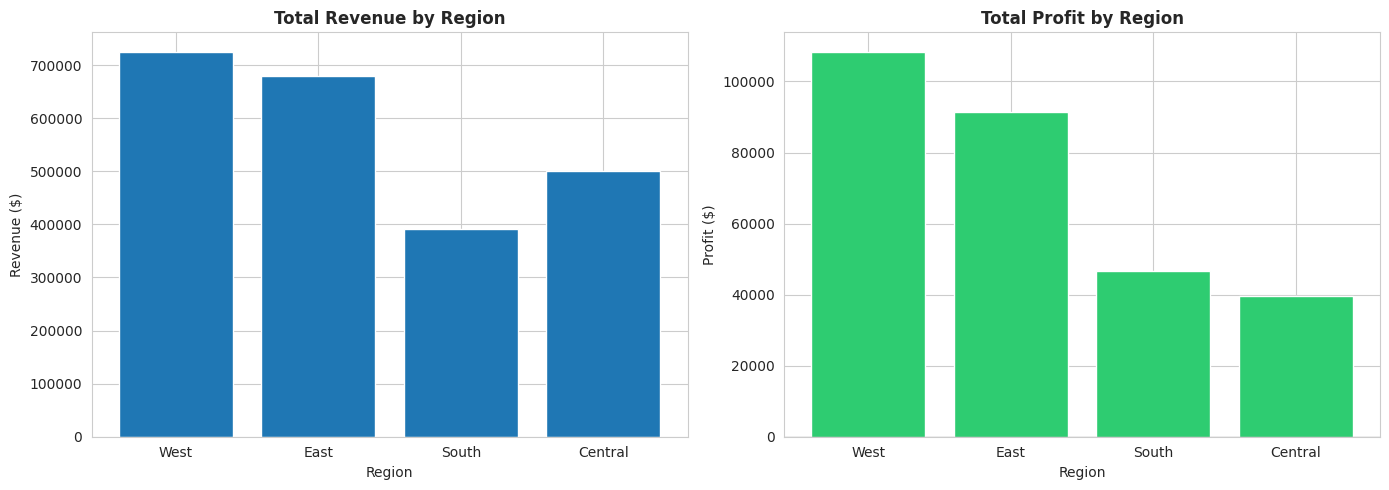

In [21]:
query = """
SELECT
    Region,
    ROUND(SUM(Sales), 2)                  AS Total_Revenue,
    ROUND(SUM(Profit), 2)                 AS Total_Profit,
    ROUND(SUM(Profit)/SUM(Sales)*100, 2)  AS Margin_Pct,
    COUNT(DISTINCT [Order ID])             AS Total_Orders
FROM df
GROUP BY Region
ORDER BY Total_Profit DESC
"""
region_df = ps.sqldf(query)
display(region_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in region_df['Total_Profit']]
axes[0].bar(region_df['Region'], region_df['Total_Revenue'], color='#1f77b4')
axes[0].set_title('Total Revenue by Region', fontweight='bold')
axes[0].set_ylabel('Revenue ($)')
axes[0].set_xlabel('Region')

axes[1].bar(region_df['Region'], region_df['Total_Profit'], color=colors)
axes[1].set_title('Total Profit by Region', fontweight='bold')
axes[1].set_ylabel('Profit ($)')
axes[1].set_xlabel('Region')
axes[1].axhline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.savefig('regional_performance.png', dpi=150, bbox_inches='tight')
plt.show()

##  Section 7 — Discount Impact Analysis
Business Question: Are discounts helping sales or destroying profit?

,Discount_Band,Total_Orders,Avg_Order_Value,Avg_Profit,Margin_Pct
0,0% - No Discount,2644,226.74,66.90,29.51
1,1-20% Discount,2507,222.59,26.50,11.91
2,21-40% Discount,400,509.00,-77.86,-15.30
3,41%+ Discount,737,137.87,-106.71,-77.40


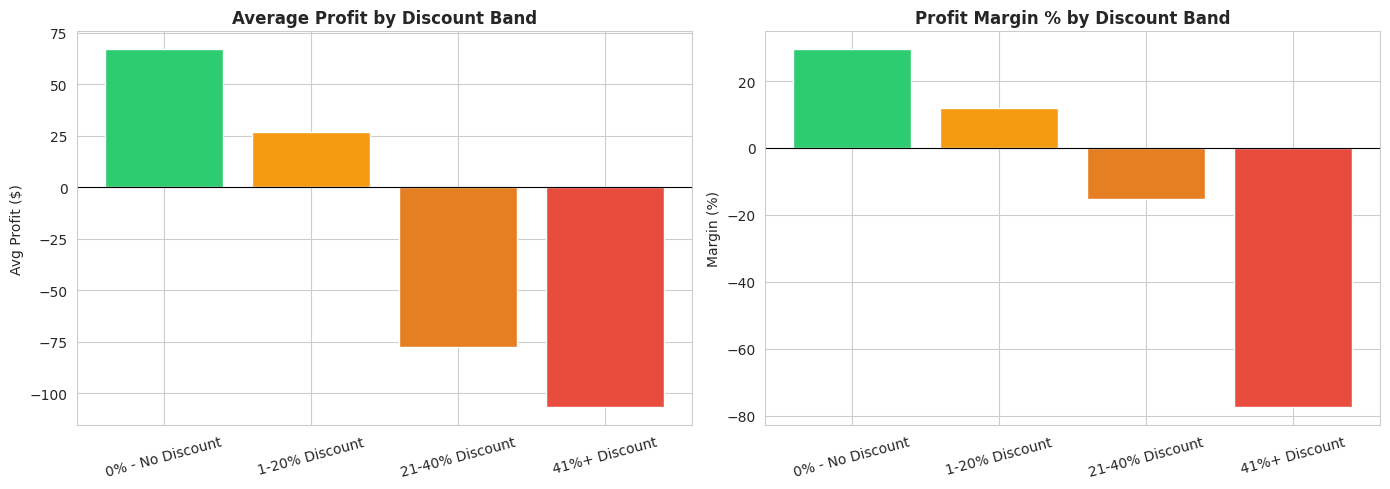

In [22]:
query = """
SELECT
    CASE
        WHEN Discount = 0 THEN '0% - No Discount'
        WHEN Discount <= 0.2 THEN '1-20% Discount'
        WHEN Discount <= 0.4 THEN '21-40% Discount'
        ELSE '41%+ Discount'
    END AS Discount_Band,
    COUNT(DISTINCT [Order ID])               AS Total_Orders,
    ROUND(AVG(Sales), 2)                     AS Avg_Order_Value,
    ROUND(AVG(Profit), 2)                    AS Avg_Profit,
    ROUND(SUM(Profit)/SUM(Sales)*100, 2)     AS Margin_Pct
FROM df
GROUP BY Discount_Band
ORDER BY Margin_Pct DESC
"""
disc_df = ps.sqldf(query)
display(disc_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c']
axes[0].bar(disc_df['Discount_Band'], disc_df['Avg_Profit'], color=colors)
axes[0].set_title('Average Profit by Discount Band', fontweight='bold')
axes[0].set_ylabel('Avg Profit ($)')
axes[0].tick_params(axis='x', rotation=15)
axes[0].axhline(0, color='black', linewidth=0.8)

axes[1].bar(disc_df['Discount_Band'], disc_df['Margin_Pct'], color=colors)
axes[1].set_title('Profit Margin % by Discount Band', fontweight='bold')
axes[1].set_ylabel('Margin (%)')
axes[1].tick_params(axis='x', rotation=15)
axes[1].axhline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.savefig('discount_impact.png', dpi=150, bbox_inches='tight')
plt.show()

##  Final Summary — Key Business Insights

This analysis examined 9,994 retail transactions across 4 years (2014–2017).
Below are the 5 most critical findings and their business implications.

In [24]:

print("        RETAIL SALES INTELLIGENCE — FINAL SUMMARY")

print("""
 OVERVIEW
─────────────────────────────────────────────────────────
  Total Revenue:      $2,297,200
  Total Profit:       $286,397
  Overall Margin:     12.47%
  Date Range:         2014 → 2017

 KEY FINDINGS
─────────────────────────────────────────────────────────
  1. CATEGORY PERFORMANCE
     • Technology leads with 17.4% margin
     • Furniture is critical risk at only 2.49% margin
     • Office Supplies is stable at 17%

  2. LOSS-MAKING PRODUCTS
     • 15+ products operating at negative profit
     • Worst offender: Cubify 3D Printer (-$8,879)
     • Machines & Tables are systematically unprofitable

  3. REVENUE GROWTH
     • 2015 saw -2.83% revenue decline
     • Strong recovery: +29.47% in 2016, +20.36% in 2017
     • Business nearly doubled from 2014 to 2017

  4. REGIONAL PERFORMANCE
     • West leads with 14.94% margin
     • Central is weakest at only 7.92% margin
     • South has lowest revenue but stable margin

  5. DISCOUNT IMPACT * CRITICAL FINDING
     • No discount orders → 29.51% margin
     • 41%+ discount orders → -77.40% margin
     • Heavy discounting is the root cause of low profitability

* RECOMMENDATIONS
─────────────────────────────────────────────────────────
  1. Cap discounts at 20% across all categories
  2. Review or discontinue loss-making Machines & Tables
  3. Investigate Central region pricing strategy
  4. Expand Technology category — highest margin potential
  5. Set minimum margin threshold before approving discounts
""")


print("  Analysis by: aziz iben hadj abdallah  | Tool: Python + SQL | 2025")


        RETAIL SALES INTELLIGENCE — FINAL SUMMARY

 OVERVIEW
─────────────────────────────────────────────────────────
  Total Revenue:      $2,297,200
  Total Profit:       $286,397
  Overall Margin:     12.47%
  Date Range:         2014 → 2017

 KEY FINDINGS
─────────────────────────────────────────────────────────
  1. CATEGORY PERFORMANCE
     • Technology leads with 17.4% margin
     • Furniture is critical risk at only 2.49% margin
     • Office Supplies is stable at 17%

  2. LOSS-MAKING PRODUCTS
     • 15+ products operating at negative profit
     • Worst offender: Cubify 3D Printer (-$8,879)
     • Machines & Tables are systematically unprofitable

  3. REVENUE GROWTH
     • 2015 saw -2.83% revenue decline
     • Strong recovery: +29.47% in 2016, +20.36% in 2017
     • Business nearly doubled from 2014 to 2017

  4. REGIONAL PERFORMANCE
     • West leads with 14.94% margin
     • Central is weakest at only 7.92% margin
     • South has lowest revenue but stable margin

  5. D

In [25]:
from google.colab import files

files.download('category_performance.png')
files.download('loss_makers.png')
files.download('sales_trend.png')
files.download('regional_performance.png')
files.download('discount_impact.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>